In [1]:
import numpy as np
import matplotlib.pyplot as plt

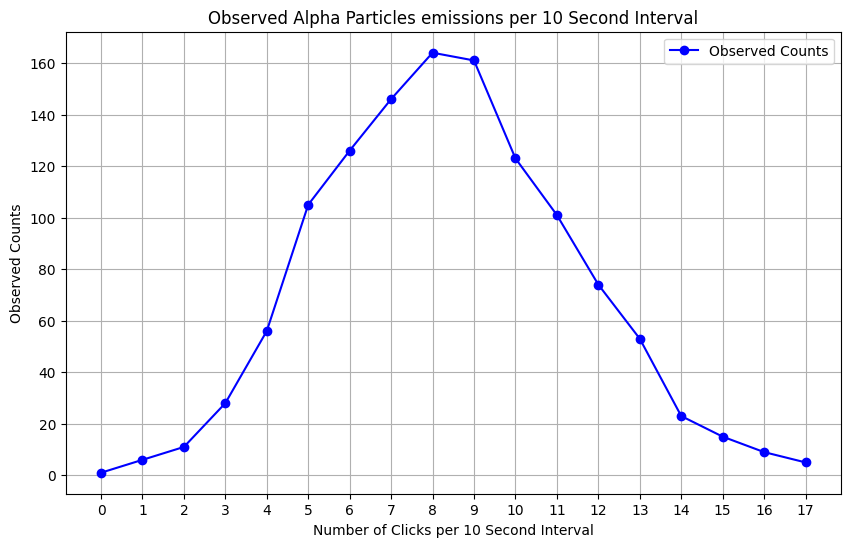

In [2]:
# 10220 Geiger Clicks (emissions) were measured, specfically time between clicks Data is binned into 10-second intervals.
# clicks per 10 second interval should be Poisson (time between is exponential) 

#data
ClicksPer10Seconds = np.arange(18) # no of counts per 10-second interval
ObservedCounts = [1,6,11,28,56,105,126,146,164,161,123,101,74,53,23,15,9,5]
# bin 1 is how many times we observed 0 alpha particle (only 1 time)
# bin 2 is how many times we observed 1 alpha particle (6 times)
# bin 3 is how many times we observed 2 alpha particles (11 times) and so on.


#plotting observed data 
plt.figure(figsize=(10,6))
plt.plot(ClicksPer10Seconds, ObservedCounts, marker='o', linestyle='-', color='blue', label='Observed Counts')

#labels and title
plt.xlabel('Number of Clicks per 10 Second Interval')
plt.ylabel('Observed Counts')
plt.title('Observed Alpha Particles emissions per 10 Second Interval')
plt.grid(True)

# set x axis to display tick marks only 
plt.xticks(ticks=np.arange(0, max(ClicksPer10Seconds)+1, 1)) #set x axis ticks to be integers from 0 to max clicks per interval
plt.legend()
plt.show()


### Best fit poisson distribution that best fits this data (what is the lambda?)

Best guess for lambda will be the sample mean X bar (expected avg of X)

Sample Mean = 8.36


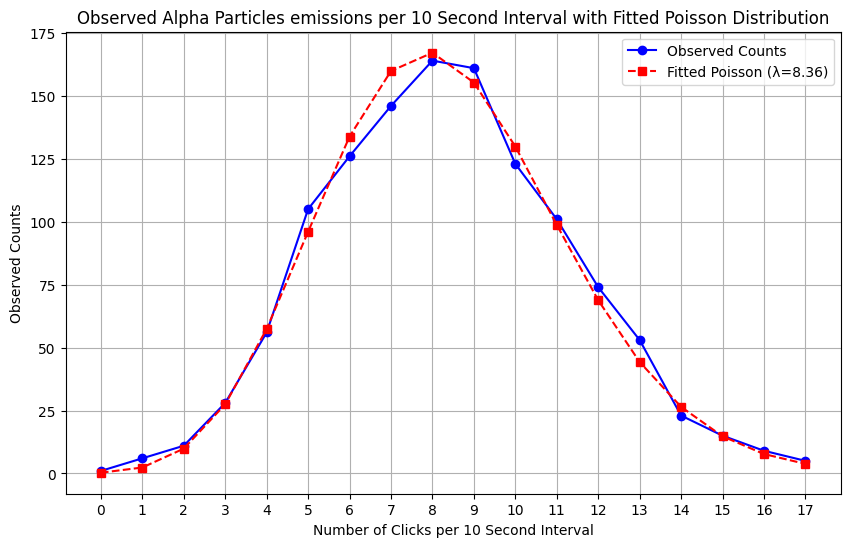

In [3]:
from scipy.stats import poisson

#calculate the sample mean
sample_mean = np.average(ClicksPer10Seconds, weights=ObservedCounts)
print(f"Sample Mean = {sample_mean:.2f}")

#fit a poisson distribution using sample mean as lambda (rate parameter)
poisson_dist = poisson.pmf(ClicksPer10Seconds, mu=sample_mean) * sum(ObservedCounts) # scale by total counts to get expected counts per bin

# plotting observed data 
plt.figure(figsize=(10,6))
plt.plot(ClicksPer10Seconds, ObservedCounts, marker='o', linestyle='-', color='blue', label='Observed Counts')

# plot fitted poisson distribution
plt.plot(ClicksPer10Seconds, poisson_dist, marker='s', linestyle='--', color='red', label=f'Fitted Poisson (λ={sample_mean:.2f})')

#labels and title
plt.xlabel('Number of Clicks per 10 Second Interval')
plt.ylabel('Observed Counts')
plt.title('Observed Alpha Particles emissions per 10 Second Interval with Fitted Poisson Distribution')
plt.grid(True)

# set x axis to display tick marks only 
plt.xticks(ticks=np.arange(0, max(ClicksPer10Seconds)+1, 1)) #set x axis ticks to be integers from 0 to max clicks per interval

plt.legend()
plt.show()



## Chi-Square Test 
only works if no of counts in a bin are more than 5
so here lets take first three counts into one bin 

Sample Mean = 8.36
Chi-Squared Statistic: 8.84
Degrees of Freedom: 14
P-value: 0.8414


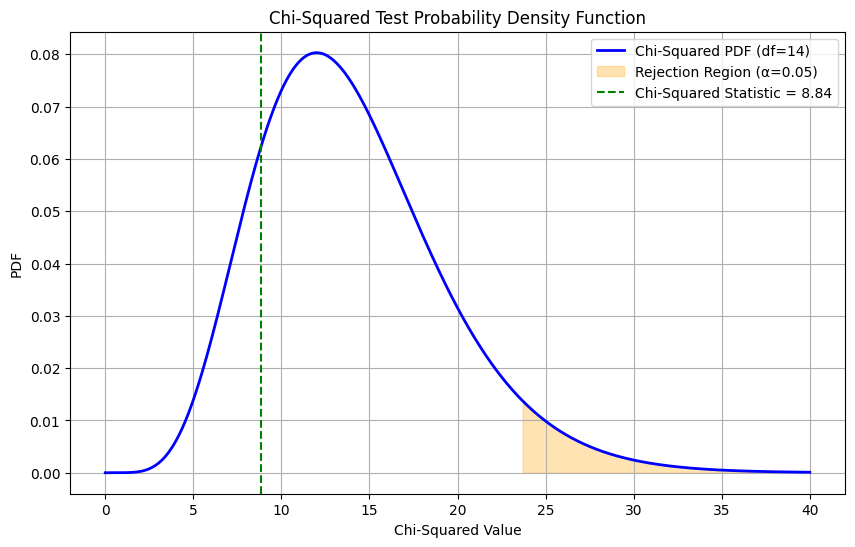

Fail to reject the null hypothesis: The data is consistent with a Poisson distribution.


In [7]:
import numpy as np
from scipy.stats import poisson, chi2
import matplotlib.pyplot as plt

# data
n = np.arange(18) # no of counts per 10-second interval
Observed = np.array([1,6,11,28,56,105,126,146,164,161,123,101,74,53,23,15,9,5]) 

# combine first three bins (0,1 and 2 counts) into one bin to ensure expected counts are at least 5
Observed_combined = np.copy(Observed)
Observed_combined[2] = np.sum(Observed[0:3]) # sum of first three bins 
Observed_combined = np.delete(Observed_combined, [0,1]) # remove the first two bins (0 and 1 counts)

# adjust n to match the combined bins
n_combined = np.copy(n)
n_combined[2] = 2 # representing counts 0,1 and 2 as one bin
n_combined = np.delete(n_combined, [0,1]) # remove the first two bins (0 and 1 counts)

# calculate the sample mean
sample_mean = np.average(n, weights=Observed)
print(f"Sample Mean = {sample_mean:.2f}")

# total number of observations
total_counts = np.sum(Observed)

# compute the expected frequencies fot each bin using poisson distribution with the sample mean as lambda
poisson_probs = poisson.pmf(n, mu=sample_mean) # probabilities for each count bin
Expected = poisson_probs * total_counts # expected counts for each bin

# combine the first three bins of expected frequencies 
Expected_combined = np.copy(Expected)
Expected_combined[2] = np.sum(Expected[0:3]) # sum of expected
Expected_combined = np.delete(Expected_combined, [0,1]) # remove the first two bins (0 and 1 counts)

# perform chi-squared test
chi_square_stat = np.sum((Observed_combined - Expected_combined)**2 / Expected_combined)
degrees_of_freedom = len(Observed_combined) - 1 - 1 # number of bins - 1 (for estimated parameter lambda)
p_value = 1 - chi2.cdf(chi_square_stat, df=degrees_of_freedom)

print(f"Chi-Squared Statistic: {chi_square_stat:.2f}")
print(f"Degrees of Freedom: {degrees_of_freedom}")
print(f"P-value: {p_value:.4f}")

# plot the chi-square pdf 
x = np.linspace(0,40, 1000)
pdf = chi2.pdf(x, df=degrees_of_freedom)

# rejection region for 95% confidence interval (alpha = 0.05)
critical_value = chi2.ppf(0.95, df=degrees_of_freedom)
rejection_region = x > critical_value

plt.figure(figsize=(10,6))
plt.plot(x, pdf,'-b', lw=2, label=f'Chi-Squared PDF (df={degrees_of_freedom})')

plt.fill_between(x, pdf, where=x >= critical_value, color='orange', alpha=0.3, label='Rejection Region (α=0.05)')
plt.axvline(chi_square_stat, color='green', linestyle='--', label=f'Chi-Squared Statistic = {chi_square_stat:.2f}')
plt.xlabel('Chi-Squared Value')
plt.ylabel('PDF')
plt.title('Chi-Squared Test Probability Density Function')
plt.legend()
plt.grid(True)
plt.show()

# print rejection criteria
if chi_square_stat > critical_value:
    print("Reject the null hypothesis: The data does not fit a (not consistent with) Poisson distribution.")
else:
    print("Fail to reject the null hypothesis: The data is consistent with a Poisson distribution.")
